/Users/juliomorales/Library/CloudStorage/GoogleDrive-juliomorales1823@gmail.com/My Drive/Graduate School/Research/Projects/Helioseismology/Morales_2025a/Code/functions.py:651: RuntimeWarning: divide by zero encountered in reciprocal
  v_phase = omega_arr * kz_arr ** (-1)
/Users/juliomorales/Library/CloudStorage/GoogleDrive-juliomorales1823@gmail.com/My Drive/Graduate School/Research/Projects/Helioseismology/Morales_2025a/Code/functions.py:651: RuntimeWarning: invalid value encountered in multiply
  v_phase = omega_arr * kz_arr ** (-1)


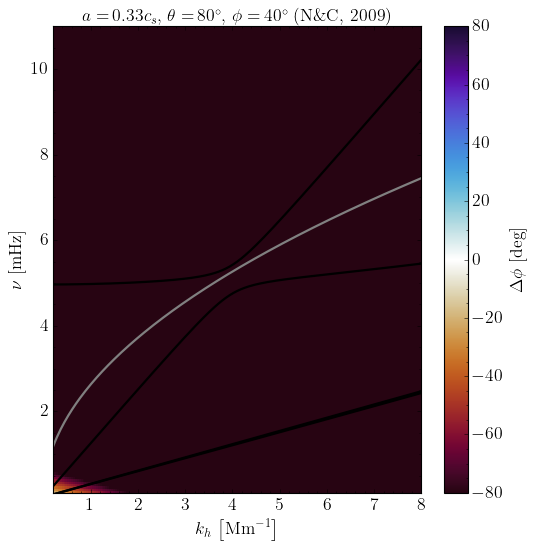

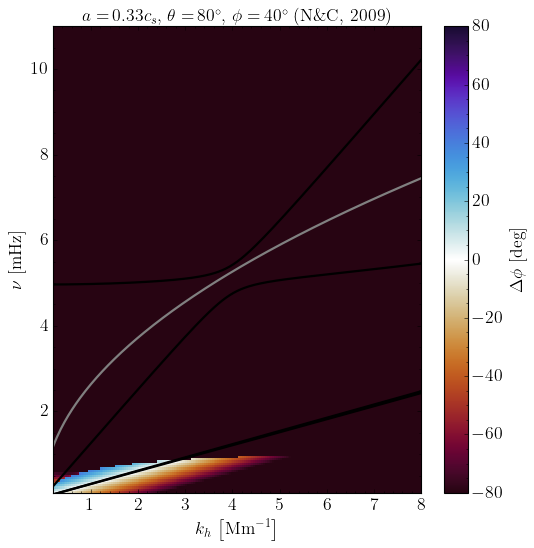

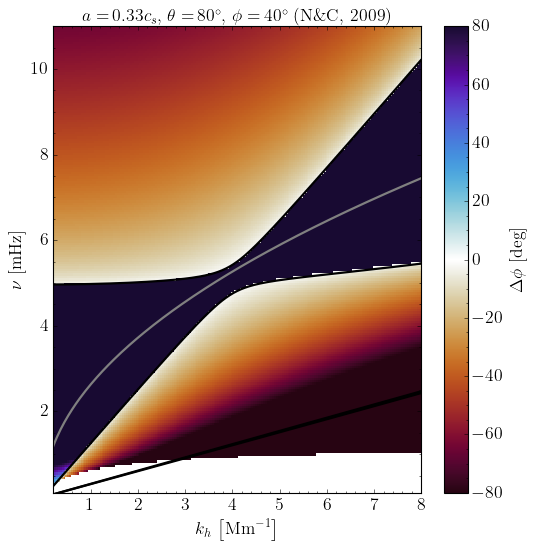

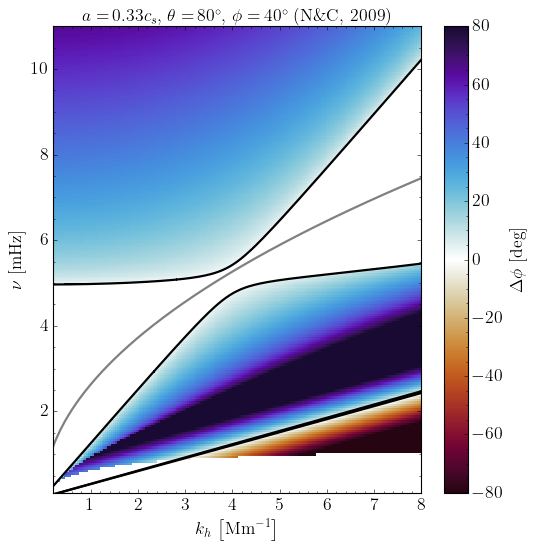

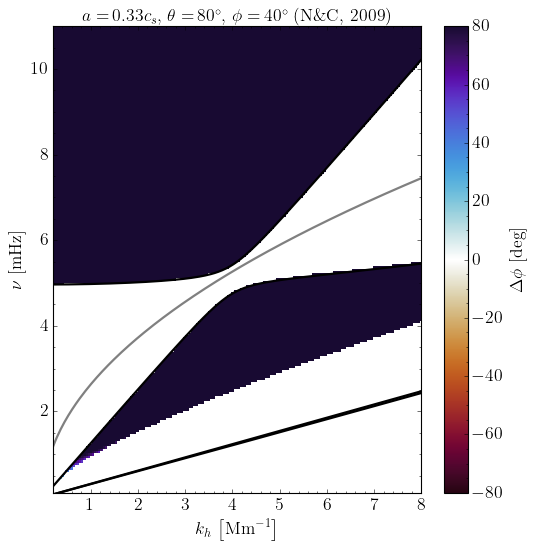

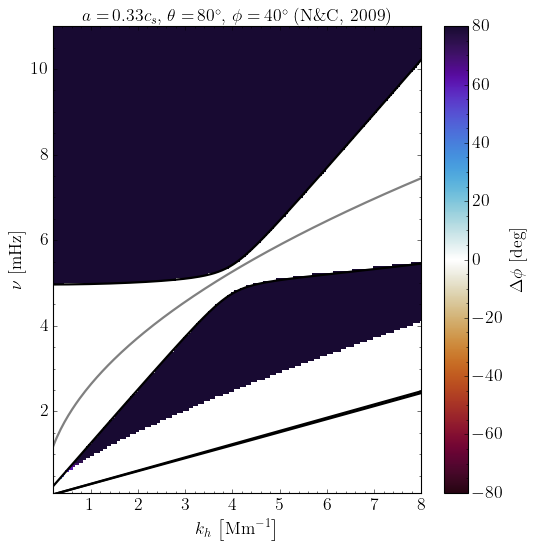

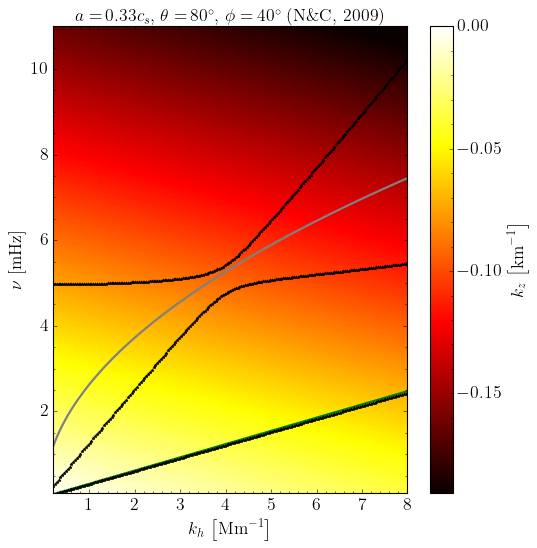

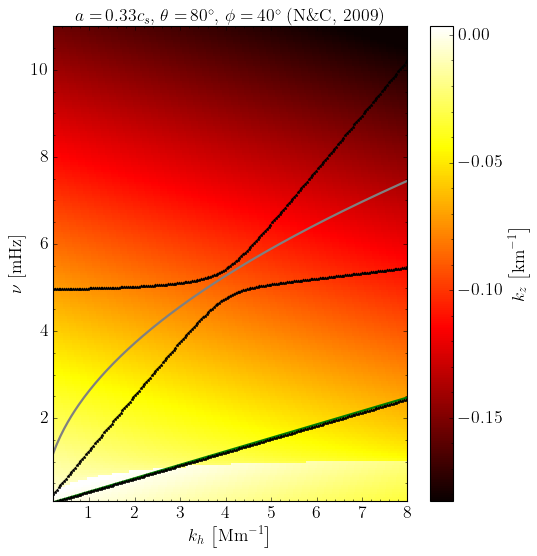

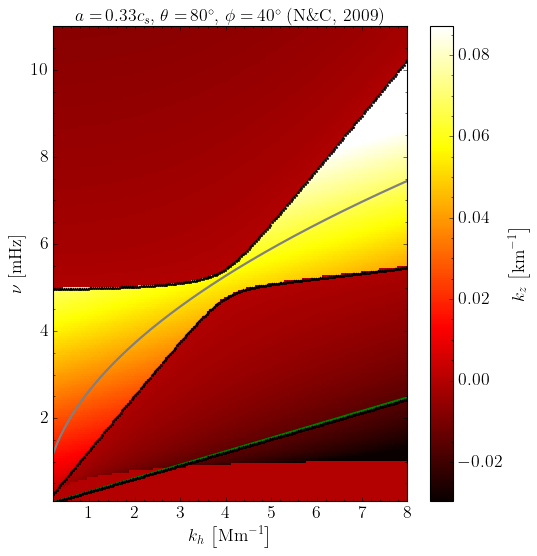

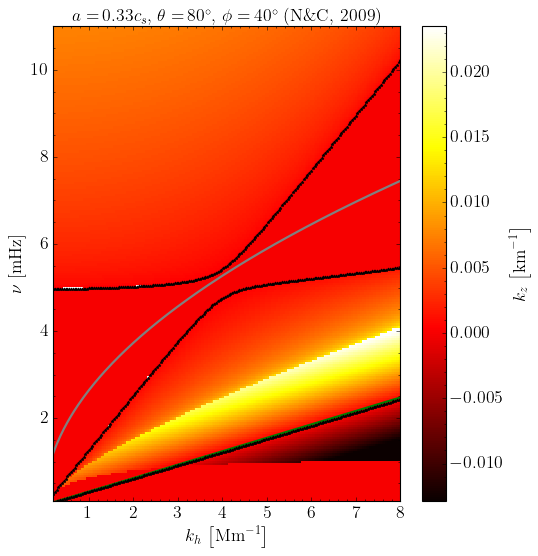

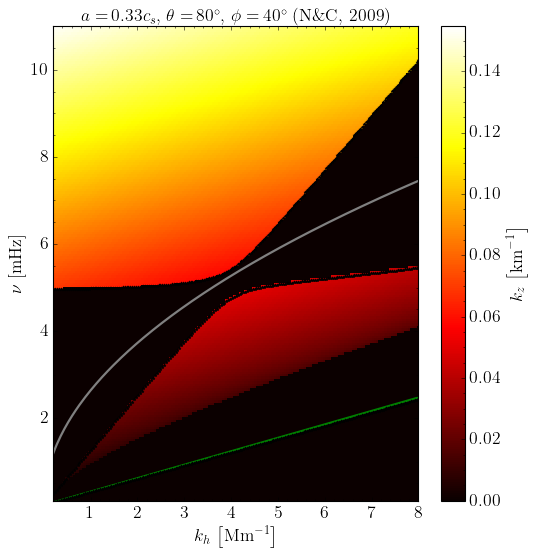

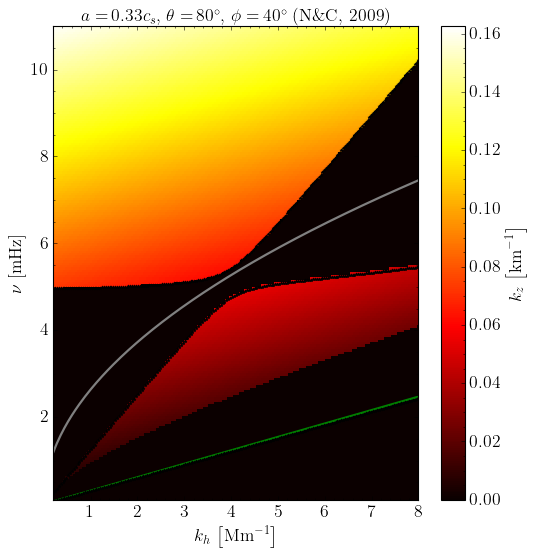

In [ ]:
# Import relevant libraries
from pathlib import Path
import sys

import numpy as np
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import cmasher as cmr
from joblib import Parallel, delayed
from astropy.visualization import ZScaleInterval
from matplotlib import rc

# Local imports (compatible with running from repo root or Code/)
root = Path.cwd()
if (root / "Code").exists():
    root_str = str(root)
    if root_str not in sys.path:
        sys.path.insert(0, root_str)
    from Code.Theory import config as dd_config
    from Code.Theory import functions as dd_funcs
else:
    import Code.Theory.config as dd_config
    import Code.Theory.functions as dd_funcs

# Create figure features
frequency_label = r"$\nu\,\left[\mathrm{mHz}\right]$"
wavenumber_label = r"$k_{h}\,\left[\mathrm{Mm}^{-1}\right]$"
colorbar_label_kz = r"$k_{z}\,\left[\mathrm{km}^{-1}\right]$"
colorbar_label_phase = r"$\Delta\phi\,\left[\mathrm{deg}\right]$"

tex_fonts = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": "Times New Roman",
    "axes.labelsize": 16,
    "font.size": 16,
    "legend.fontsize": 14,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "legend.frameon": True,
    "legend.framealpha": 0.8,
    "axes.formatter.use_mathtext": True,
    "lines.linewidth": 2,
    "ytick.minor.visible": True,
    "xtick.minor.visible": True,
    "savefig.dpi": 300,
    "pcolor.shading": "auto",
    "figure.facecolor": "white",
}

# Update matplotlib settings
plt.style.use("classic")
matplotlib.rcParams.update(tex_fonts)
rc("mathtext", **{"default": "regular"})

# Select the model
params = dd_config.params
model = "nc2009"
model_params = params[model]

# Define grids
kh = np.linspace(0.0, 8.0, 200) * 1e-3  # km^-1
omega_mhz = np.linspace(0.0, 11.0, 200)  # mHz
omega = omega_mhz * 2 * np.pi * 1e-3  # rad/s

requires_nonzero_omega = model in {"sf1966", "mt1981", "mt1982"} or (
    model == "bunte1993" and np.isclose(model_params.get("a", 0.0), 0.0, rtol=1e-09, atol=1e-09)
)
if requires_nonzero_omega and np.isclose(omega[0], 0.0, rtol=1e-09, atol=1e-09):
    omega = omega.copy()
    omega[0] = np.nextafter(0.0, 1.0)

kh_grid, omega_grid = np.meshgrid(kh, omega)  # km^-1, rad/s

# Initialize the diagnostic diagram
analysis = dd_funcs.DiagnosticDiagram(kh_grid, omega_grid, model_params)

# Conversion factors
rad_to_mhz = 1e3 / (2 * np.pi)  # rad/s to mHz
inv_km_to_Mm = 1e3  # km^-1 to Mm^-1

# Calculate the bounds where kz^2 < 0 and calculate kz
omega_roots = Parallel(n_jobs=-1, backend="loky")(
    delayed(analysis.omega_solve)(value) for value in kh
)
nu = np.array(omega_roots) * rad_to_mhz

kz_roots = Parallel(n_jobs=-1, backend="loky")(
    delayed(analysis.kz_solve)(value) for value in kh
)
kz = np.stack(kz_roots, axis=1)

# Calculate grids and f-mode dispersion for plotting
kh_plot = kh_grid * inv_km_to_Mm  # Mm^-1
nu_plot = omega_grid * rad_to_mhz  # mHz
fmode_nu = analysis.fmode_dispersion() * rad_to_mhz

# Subtract mode contamination
if model == "nc2009":
    evan_indices = np.nonzero((nu_plot >= nu[:, 1]) & (nu_plot <= nu[:, 2]))
    kz[:, :, 3][evan_indices] = 0.0

# Calculate the corresponding phase speed and phase difference per kz-mode
kz_order = model_params["kz_order"]
omega_order = model_params["omega_order"]
v_phase = [analysis.phase_speed(omega_grid, kz[:, :, n]) for n in range(kz_order)]
v_phase_clean = [
    np.where(np.isfinite(vp), vp, np.finfo(float).max) for vp in v_phase
]
delta_phi = [
    analysis.phase_difference(omega_grid, v_phase_clean[n], dd_config.dz)
    for n in range(kz_order)
]

# Plot the diagnostic diagram
interval = ZScaleInterval()

# Plot the phase differences
for i in range(kz_order):
    phase_difference = np.nan_to_num(
        delta_phi[i] * 180 * np.pi ** (-1), nan=0.0, posinf=0.0, neginf=0.0
    )
    if np.all(np.isclose(phase_difference, 0.0, rtol=1e-9, atol=1e-9)):
        plt.close()
        continue

    plt.figure(figsize=(7, 7))
    plt.plot(kh_plot[0], fmode_nu, "gray")
    if model in {"nc2009", "bunte1993"}:
        plt.plot(kh_plot[0], kh * (dd_config.ax * rad_to_mhz), color="black", linestyle="-")
    vmin, vmax = -80, 80
    plt.pcolormesh(
        kh_plot,
        nu_plot,
        phase_difference,
        cmap=cmr.fusion,
        shading="auto",
        norm=mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax),
        rasterized=True,
    )
    plt.colorbar(label=colorbar_label_phase)
    for j in range(omega_order):
        plt.plot(kh_plot[0], nu[:, j], "k-", markersize=3)
    plt.xlabel(wavenumber_label)
    plt.ylabel(frequency_label)
    plt.xlim(0.2, np.max(kh_plot))
    plt.ylim(0.1, np.max(nu_plot))
    plt.tight_layout()
    plt.title(model_params["title"])
    plt.show()

# Plot the kz grids
for i in range(kz_order):
    kz_i = kz[:, :, i]
    if np.all(np.isclose(kz_i, 0.0, rtol=1e-9, atol=1e-9)):
        plt.close()
        continue

    plt.figure(figsize=(7, 7))
    plt.plot(kh_plot[0], fmode_nu, "gray")
    if model in {"nc2009", "bunte1993"}:
        plt.plot(kh_plot[0], kh * dd_config.ax * rad_to_mhz, color="green", linestyle="-")
    vmin, vmax = interval.get_limits(kz_i)
    plt.pcolormesh(
        kh_plot,
        nu_plot,
        kz_i,
        cmap="hot",
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        rasterized=True,
    )
    plt.colorbar(label=colorbar_label_kz)
    for j in range(omega_order):
        plt.plot(kh_plot[0], nu[:, j], "k*", markersize=3)
    plt.xlabel(wavenumber_label)
    plt.ylabel(frequency_label)
    plt.xlim(0.2, np.max(kh_plot))
    plt.ylim(0.1, np.max(nu_plot))
    plt.tight_layout()
    plt.title(model_params["title"])
    plt.show()


In [2]:
# Sanity checks
expected_nu_shape = (kh.size, omega_order)
expected_kz_shape = (omega.size, kh.size, kz_order)
assert nu.shape == expected_nu_shape, f"nu shape {nu.shape} != {expected_nu_shape}"
assert kz.shape == expected_kz_shape, f"kz shape {kz.shape} != {expected_kz_shape}"
assert np.isfinite(nu).all(), "nu contains NaN or inf"
assert np.isfinite(kz).all(), "kz contains NaN or inf"
print("Sanity checks passed.")
print(f"nu shape: {nu.shape}, range: {nu.min():.6g} to {nu.max():.6g} mHz")
print(f"kz shape: {kz.shape}, range: {kz.min():.6g} to {kz.max():.6g} km^-1")


Sanity checks passed.
nu shape: (200, 6), range: 0 to 10.2217 mHz
kz shape: (200, 200, 6), range: -0.197407 to 0.162609 km^-1
